In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("Heart Attack Data Set.csv")

df.rename(columns={
    'cp': 'chest_pain',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_bs',
    'restecg': 'resting_ecg',
    'thalach': 'max_hr',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'major_vessels',
    'thal': 'thalassemia'
}, inplace=True)

df.head()

,age,sex,chest_pain,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,st_depression,st_slope,major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.drop_duplicates(inplace=True)

### EDA - Exploratory Data Analysis

In [4]:
df.isnull().sum()

age                0
sex                0
chest_pain         0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
st_depression      0
st_slope           0
major_vessels      0
thalassemia        0
target             0
dtype: int64

In [5]:
df.describe()

,age,sex,chest_pain,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,st_depression,st_slope,major_vessels,thalassemia,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              302 non-null    int64  
 1   sex              302 non-null    int64  
 2   chest_pain       302 non-null    int64  
 3   resting_bp       302 non-null    int64  
 4   cholesterol      302 non-null    int64  
 5   fasting_bs       302 non-null    int64  
 6   resting_ecg      302 non-null    int64  
 7   max_hr           302 non-null    int64  
 8   exercise_angina  302 non-null    int64  
 9   st_depression    302 non-null    float64
 10  st_slope         302 non-null    int64  
 11  major_vessels    302 non-null    int64  
 12  thalassemia      302 non-null    int64  
 13  target           302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [7]:
df.target.value_counts()

target
1    164
0    138
Name: count, dtype: int64

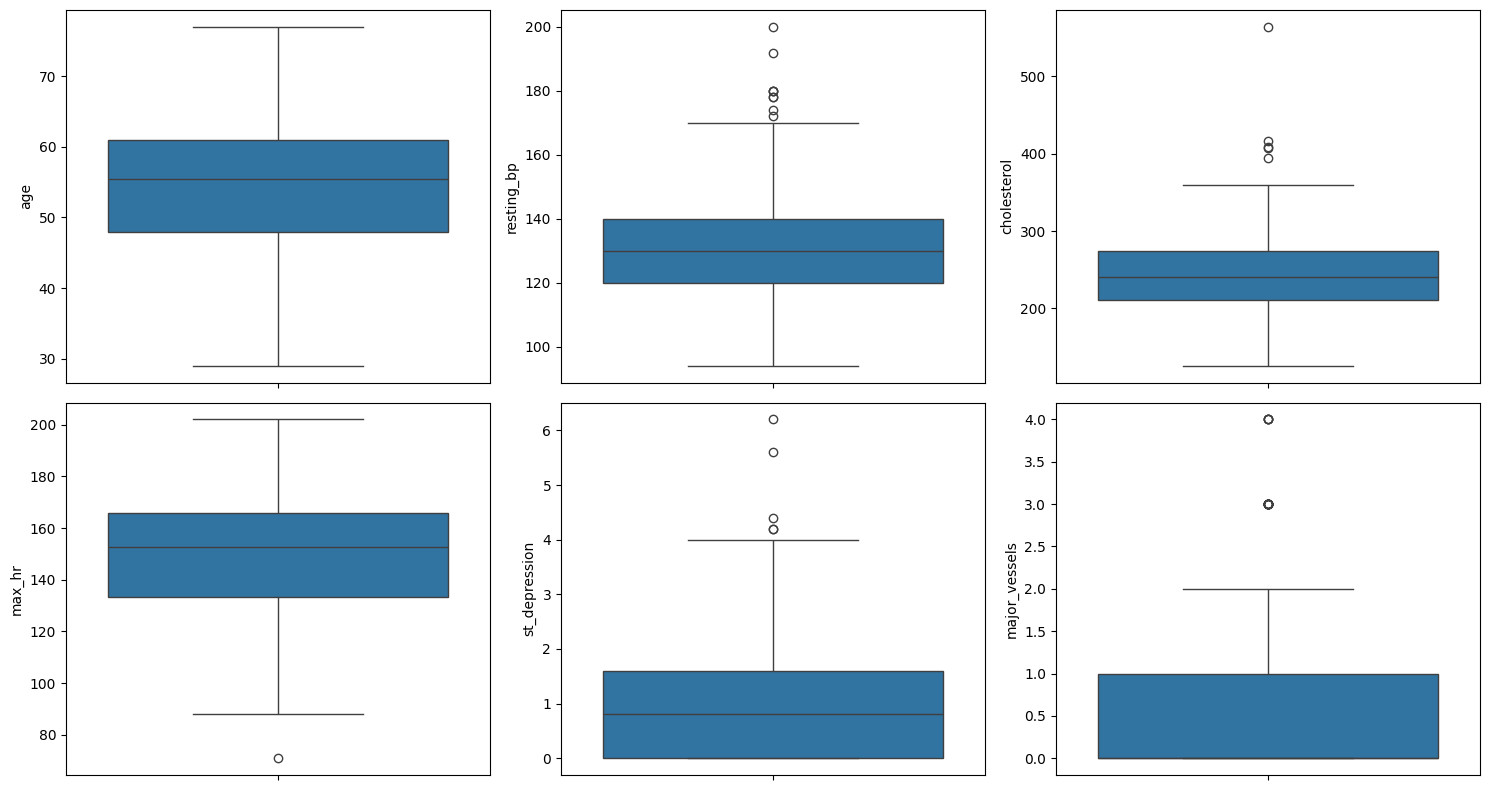

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(['age', 'resting_bp', 'cholesterol', 'max_hr', 'st_depression', 'major_vessels']):
    sns.boxplot(data=df, y=col, ax=axes[i//3][i%3])
plt.tight_layout()
plt.show()

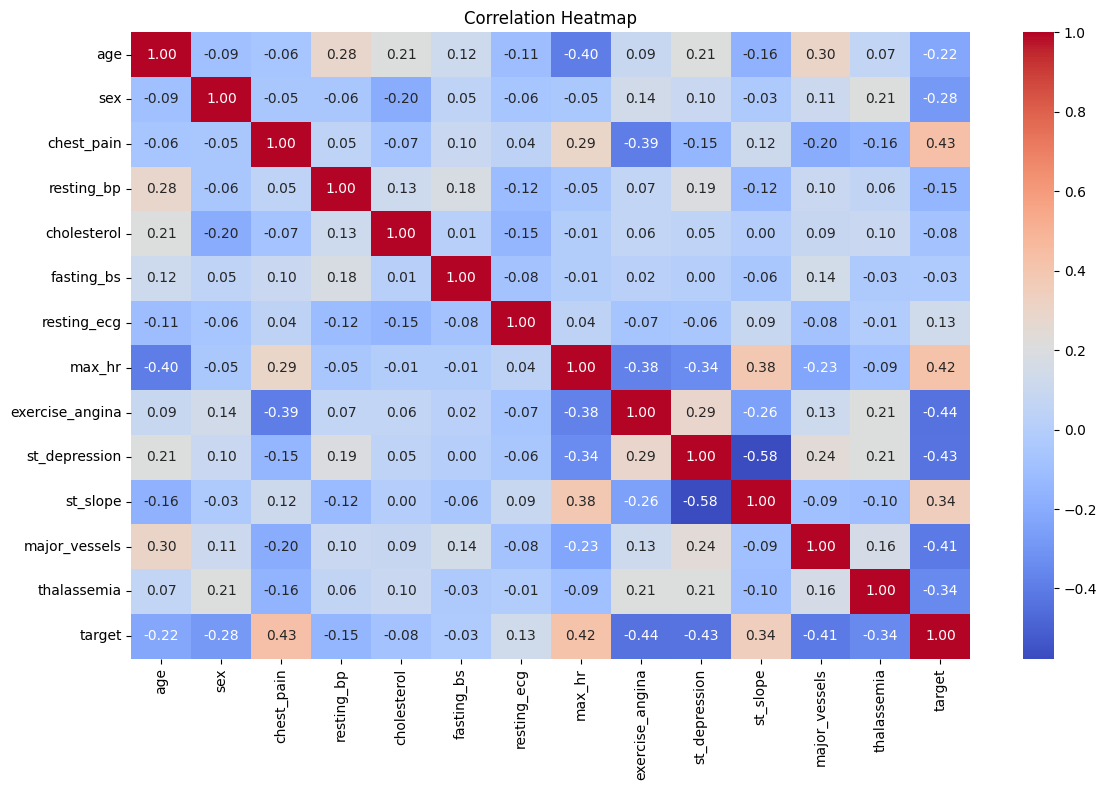

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

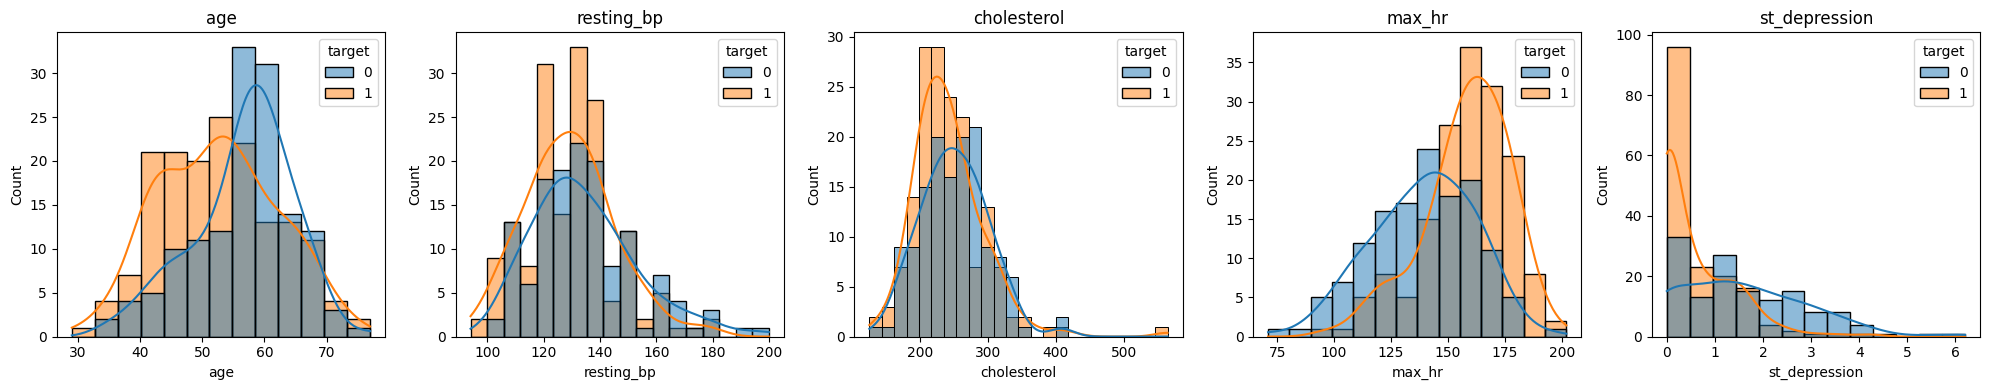

In [11]:
continuous = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'st_depression']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(continuous):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

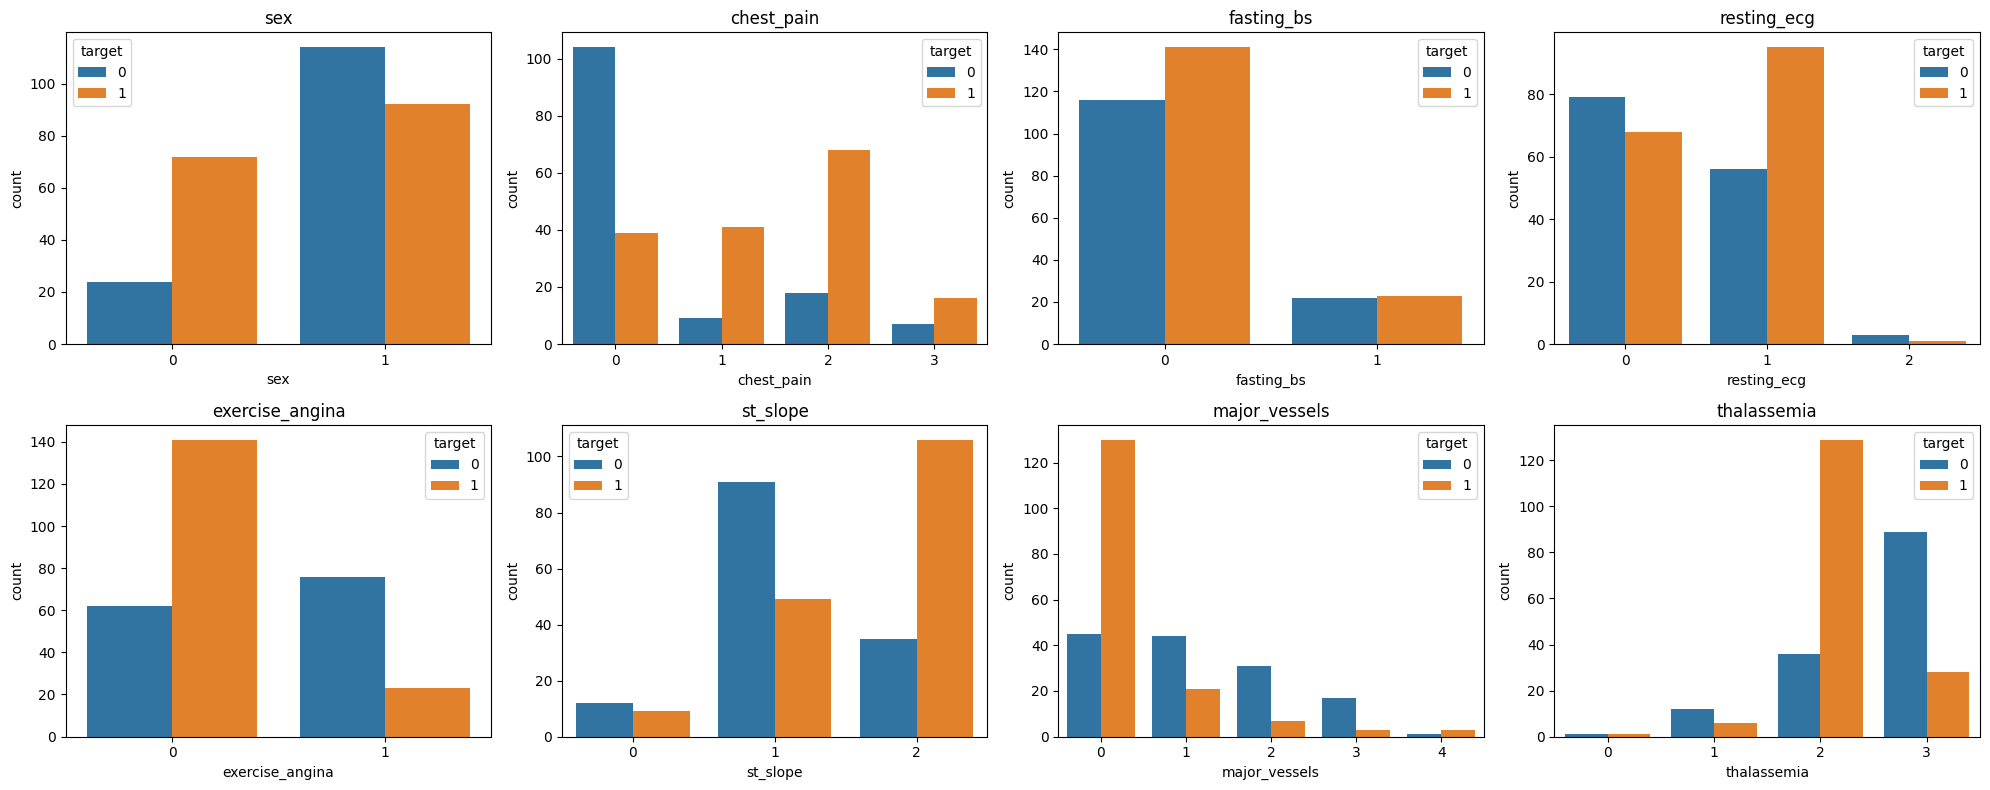

In [12]:
categorical = ['sex', 'chest_pain', 'fasting_bs', 'resting_ecg', 'exercise_angina', 'st_slope', 'major_vessels', 'thalassemia']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, col in enumerate(categorical):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i//4][i%4])
    axes[i//4][i%4].set_title(col)
plt.tight_layout()
plt.show()

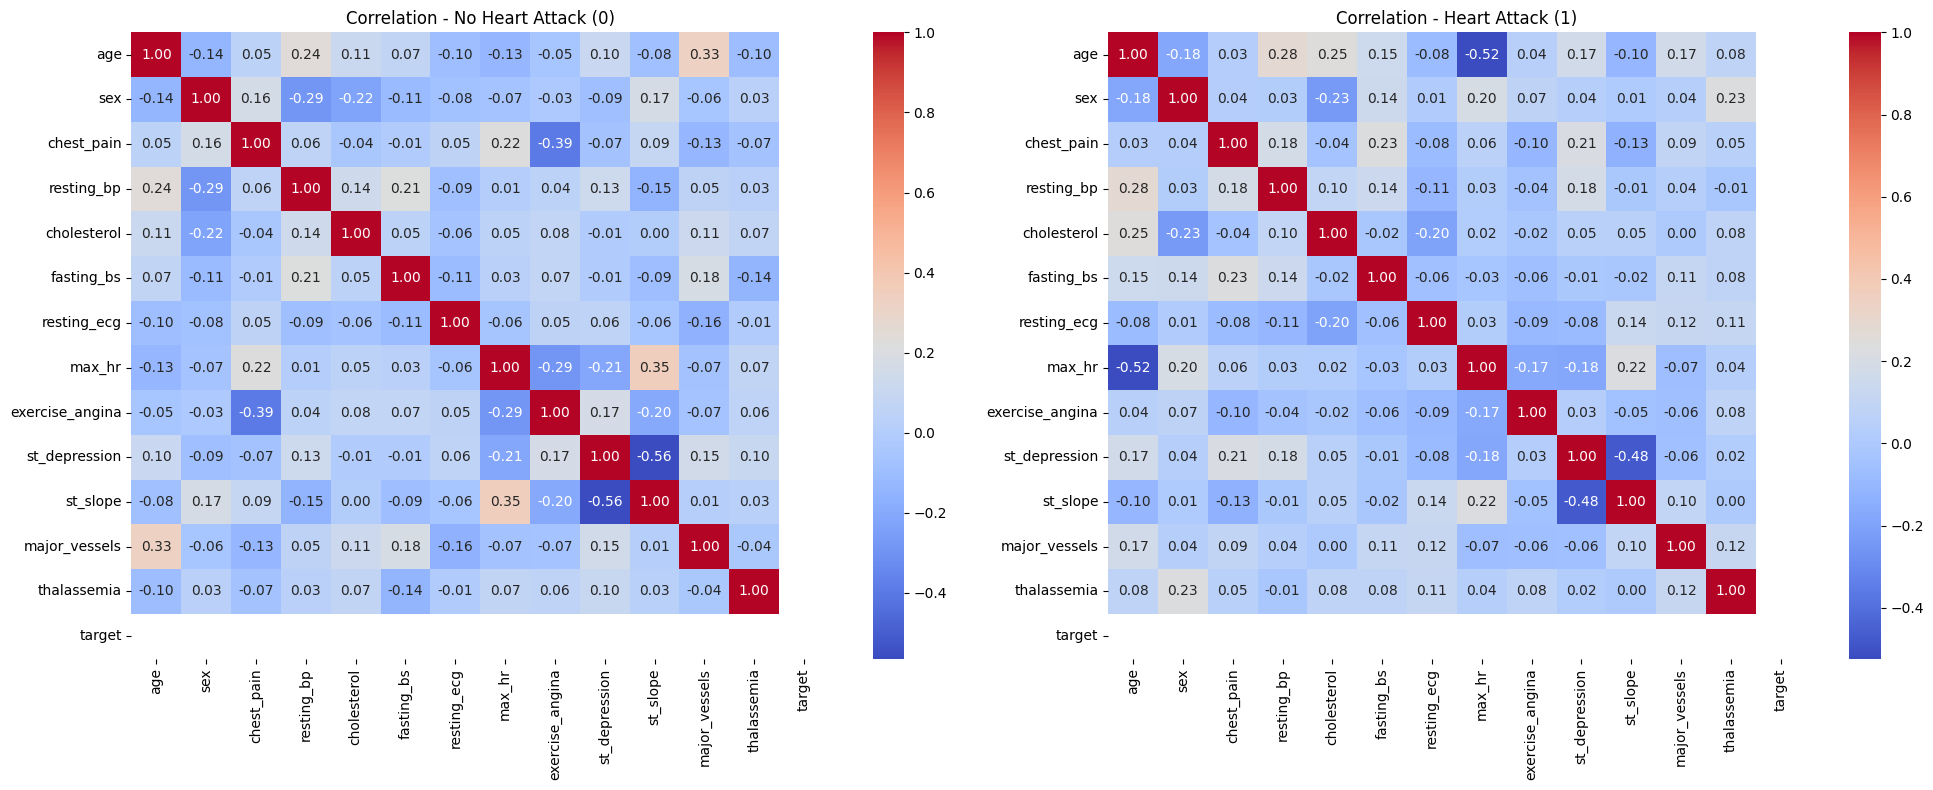

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(df[df['target'] == 0].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Correlation - No Heart Attack (0)')

sns.heatmap(df[df['target'] == 1].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation - Heart Attack (1)')

plt.tight_layout()
plt.show()

### Train Test Split

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42)

### Feature Engineering

In [15]:
def count_outlier_rows(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = ((df < Q1 - 1.5 * IQR) | (df > Q3 + 1.5 * IQR)).any(axis=1)
    print(f"Rows with at least one outlier: {outlier_mask.sum()} / {len(df)}")

count_outlier_rows(X_train)

Rows with at least one outlier: 55 / 241


In [16]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train = X_train.clip(lower=lower, upper=upper, axis=1)
X_test = X_test.clip(lower=lower, upper=upper, axis=1)

count_outlier_rows(X_train)

Rows with at least one outlier: 0 / 241


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Baseline Models

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

print(f"\nBest: {max(results, key=results.get)} ({max(results.values()):.4f})")

Logistic Regression: 0.8525
Random Forest: 0.8689
SVM: 0.8852
KNN: 0.8852

Best: SVM (0.8852)


### Hyperparameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV

# SVM
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)

print(f"SVM Best Params: {svm_grid.best_params_}")
print(f"SVM Best CV Score: {svm_grid.best_score_:.4f}")

SVM Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
SVM Best CV Score: 0.8633


In [20]:
# KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

print(f"KNN Best Params: {knn_grid.best_params_}")
print(f"KNN Best CV Score: {knn_grid.best_score_:.4f}")

KNN Best Params: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
KNN Best CV Score: 0.8384


### Final Evaluation

--- SVM (tuned) (Test Accuracy: 0.8525) ---
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

--- KNN (tuned) (Test Accuracy: 0.8525) ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



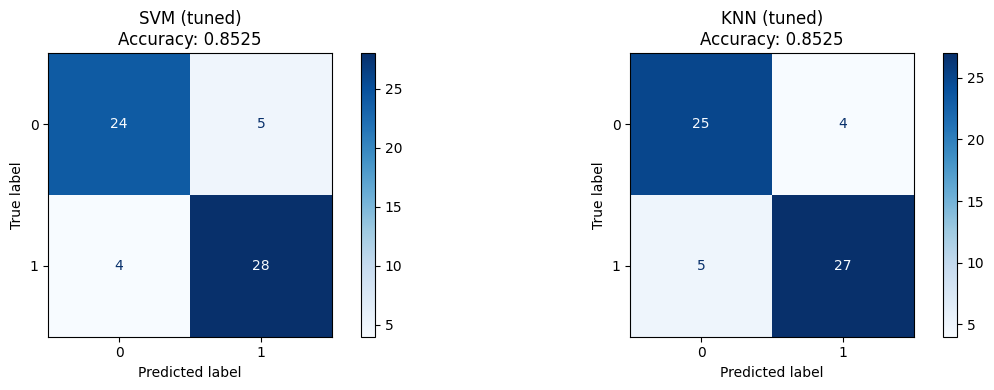

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

tuned_models = {
    'SVM (tuned)': svm_grid.best_estimator_,
    'KNN (tuned)': knn_grid.best_estimator_
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print(f"--- {name} (Test Accuracy: {acc:.4f}) ---")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i], cmap='Blues')
    axes[i].set_title(f"{name}\nAccuracy: {acc:.4f}")

plt.tight_layout()
plt.show()

### Save Pipeline

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        Q1 = pd.DataFrame(X).quantile(0.25)
        Q3 = pd.DataFrame(X).quantile(0.75)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.factor * IQR
        self.upper_ = Q3 + self.factor * IQR
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        return df.clip(lower=self.lower_, upper=self.upper_, axis=1).values

pipeline = Pipeline([
    ('clipper', OutlierClipper()),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='uniform'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Pipeline Accuracy: {accuracy_score(y_test, y_pred):.4f}")

joblib.dump(pipeline, 'pipeline.pkl')
print("Pipeline saved!")

Pipeline Accuracy: 0.8525
Pipeline saved!


In [23]:
pipeline = joblib.load('pipeline.pkl')

new_patient = pd.DataFrame([{
    'age': 55,
    'sex': 1,
    'chest_pain': 2,
    'resting_bp': 140,
    'cholesterol': 250,
    'fasting_bs': 0,
    'resting_ecg': 1,
    'max_hr': 160,
    'exercise_angina': 0,
    'st_depression': 1.5,
    'st_slope': 1,
    'major_vessels': 0,
    'thalassemia': 2
}])

result = pipeline.predict(new_patient)
print(f"Prediction: {'Heart Attack Risk' if result[0] == 1 else 'No Heart Attack Risk'}")

Prediction: Heart Attack Risk
